In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [37]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
df.shape

(42000, 785)

In [39]:
df.sample(1)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
103,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


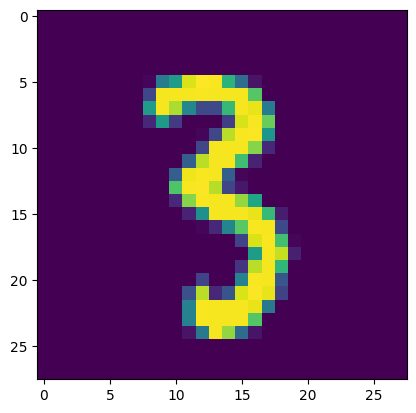

In [40]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[8729, 1:].values.reshape(28,28))

In [43]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [45]:
X_train.shape

(33600, 784)

In [46]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [47]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [48]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

9.420526027679443


In [49]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9648809523809524

In [50]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy', n_jobs=-1)

mean_accuracy = np.mean(cv_scores)

print(f"All fold scores: {cv_scores}")
print(f"Mean CV Accuracy: {mean_accuracy:.4f}")

All fold scores: [0.96797619 0.96559524 0.96345238 0.96333333 0.96892857]
Mean CV Accuracy: 0.9659


In [51]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [52]:
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [63]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 200)

In [64]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [65]:
X_train_trf.shape

(33600, 200)

In [66]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train )

KNeighborsClassifier()

In [67]:
y_pred_trf = knn.predict(X_test_trf)

In [68]:
accuracy_score(y_test, y_pred_trf)

0.9507142857142857

In [69]:
for i in range(1, 785):
    pca = PCA(n_components = i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf,y_train )
    y_pred_trf = knn.predict(X_test_trf)
    print(accuracy_score(y_test, y_pred_trf))
    
    

0.2580952380952381
0.3236904761904762
0.5104761904761905
0.6663095238095238
0.7378571428571429
0.8227380952380953
0.8436904761904762
0.8721428571428571
0.886547619047619
0.9055952380952381
0.9116666666666666
0.9184523809523809
0.9276190476190476
0.9351190476190476
0.9384523809523809
0.9379761904761905
0.9407142857142857
0.94
0.9425
0.9442857142857143
0.9438095238095238
0.9441666666666667
0.9442857142857143
0.9457142857142857
0.9484523809523809
0.9479761904761905
0.9478571428571428
0.9471428571428572
0.949047619047619
0.9491666666666667
0.9507142857142857
0.9513095238095238
0.95
0.9504761904761905
0.950952380952381
0.9519047619047619
0.9517857142857142
0.9527380952380953
0.9533333333333334
0.9528571428571428
0.9522619047619048
0.9522619047619048
0.9523809523809523
0.9533333333333334
0.9528571428571428
0.9530952380952381
0.9530952380952381
0.9533333333333334
0.9527380952380953
0.9533333333333334
0.9545238095238096
0.954047619047619
0.9541666666666667
0.9541666666666667
0.9546428571428571

KeyboardInterrupt: 

In [71]:
pca.explained_variance_
# Eigen values of the n components

array([40.67111198, 29.17023401, 26.74459621, 20.85344792, 18.14891878,
       15.8529825 , 13.87108101, 12.48058967, 11.02794236, 10.09582533,
        9.63317821,  8.62785945,  8.06303131,  7.89511749,  7.44167929,
        7.17032873,  6.73266373,  6.62744023,  6.41499161,  6.25808269,
        5.90495742,  5.76521585,  5.52084601,  5.32003847,  5.18309925,
        4.93439597,  4.90652171,  4.71800493,  4.49824444,  4.43140305,
        4.32604521,  4.23491831,  4.10335015,  4.0673118 ,  4.02362178,
        3.84130473,  3.81886146,  3.71316498,  3.60918108,  3.47303214,
        3.42842989,  3.38841159,  3.29157511,  3.22927379,  3.21745142,
        3.15810372,  3.12620905,  3.10412385,  3.05892795,  3.03728188,
        2.96540461,  2.94033669,  2.86828564,  2.82617865,  2.80038441,
        2.77411221,  2.71978838,  2.69394232,  2.64724369,  2.63065837,
        2.56498699,  2.53651735,  2.48789582,  2.44610051,  2.42066567,
        2.37577156,  2.35505085,  2.33408709,  2.29804042,  2.25

In [72]:
pca.components_
#Eigen_vectors


array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

In [73]:
pca.components_.shape
# hence tis is for 94 n_components

(94, 784)

In [78]:
# optimum number of principle components required
pca.explained_variance_ratio_ *100
# take that number of n_compaonents such that their added percentage contribution in variance sum ups to atleast 90
    


array([5.78519225, 4.14926968, 3.80423901, 2.96626277, 2.58156168,
       2.25498018, 1.97306802, 1.77527998, 1.56865066, 1.43606328,
       1.37025484, 1.227255  , 1.146912  , 1.12302739, 1.05852885,
       1.01993106, 0.95767615, 0.94270882, 0.91248943, 0.89017019,
       0.8399405 , 0.8200632 , 0.78530323, 0.75673971, 0.73726102,
       0.70188465, 0.69791973, 0.67110448, 0.63984503, 0.63033729,
       0.61535085, 0.60238866, 0.58367397, 0.57854776, 0.57233315,
       0.54639977, 0.54320737, 0.52817275, 0.51338174, 0.49401547,
       0.4876711 , 0.48197877, 0.46820443, 0.45934249, 0.45766083,
       0.44921902, 0.44468222, 0.44154075, 0.43511194, 0.43203293,
       0.42180887, 0.41824313, 0.40799435, 0.40200491, 0.39833586,
       0.39459881, 0.38687161, 0.38319518, 0.37655262, 0.37419347,
       0.36485215, 0.36080254, 0.35388646, 0.34794135, 0.34432342,
       0.33793753, 0.33499015, 0.3320082 , 0.3268808 , 0.32050793,
       0.31877647, 0.3113891 , 0.30963318, 0.30583095, 0.30370

In [81]:
pca = PCA(n_components = None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [83]:
pca.explained_variance_.shape

(784,)

In [84]:
pca.components_.shape

(784, 784)

In [86]:
pca.explained_variance_

array([4.06711120e+01, 2.91702340e+01, 2.67445962e+01, 2.08534479e+01,
       1.81489188e+01, 1.58529825e+01, 1.38710810e+01, 1.24805897e+01,
       1.10279424e+01, 1.00958253e+01, 9.63317821e+00, 8.62785945e+00,
       8.06303131e+00, 7.89511749e+00, 7.44167929e+00, 7.17032873e+00,
       6.73266373e+00, 6.62744023e+00, 6.41499161e+00, 6.25808269e+00,
       5.90495742e+00, 5.76521585e+00, 5.52084601e+00, 5.32003847e+00,
       5.18309925e+00, 4.93439597e+00, 4.90652171e+00, 4.71800493e+00,
       4.49824444e+00, 4.43140305e+00, 4.32604521e+00, 4.23491831e+00,
       4.10335015e+00, 4.06731180e+00, 4.02362178e+00, 3.84130473e+00,
       3.81886146e+00, 3.71316498e+00, 3.60918108e+00, 3.47303214e+00,
       3.42842989e+00, 3.38841159e+00, 3.29157511e+00, 3.22927379e+00,
       3.21745142e+00, 3.15810372e+00, 3.12620905e+00, 3.10412385e+00,
       3.05892795e+00, 3.03728188e+00, 2.96540461e+00, 2.94033669e+00,
       2.86828564e+00, 2.82617865e+00, 2.80038441e+00, 2.77411221e+00,
      

In [88]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

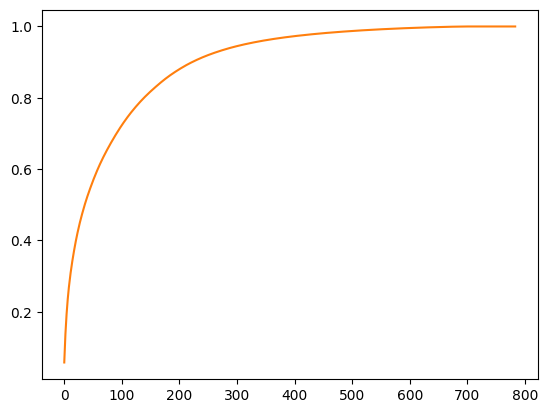

In [91]:
plt.plot(0,0.9)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt


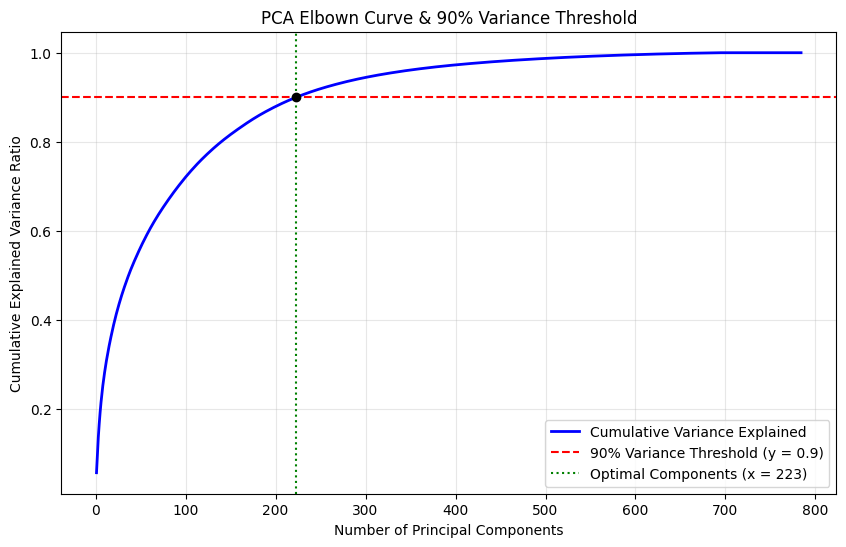

The exact number of components required to explain 90% variance is: 223


In [92]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# 2. Find the exact x-axis intersection point (index starts at 0, so add 1)
n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, label='Cumulative Variance Explained', color='blue', linewidth=2)

# 4. Add the horizontal line at y = 0.9
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance Threshold (y = 0.9)')

# 5. Add a vertical line at the intersection point to drop down to the x-axis
plt.axvline(x=n_components_90, color='g', linestyle=':', label=f'Optimal Components (x = {n_components_90})')

# 6. Mark the intersection point with a dot
plt.scatter(n_components_90, 0.9, color='black', zorder=5)

# 7. Labels, legends, and styling
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA Elbown Curve & 90% Variance Threshold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

print(f"The exact number of components required to explain 90% variance is: {n_components_90}")